In [38]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns 

from sklearn.preprocessing import StandardScaler,MinMaxScaler,FunctionTransformer
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder

In [39]:
TRAIN_PATH = Path.cwd() / "train"
TEST_PATH = Path.cwd() / "test"

In [40]:
# Load Training set 
X_train = pd.read_csv(TRAIN_PATH / "X_train.csv")
y_train = pd.read_csv(TRAIN_PATH / "y_train.csv")

# Load Testing set
X_test = pd.read_csv(TEST_PATH / "X_test.csv")
y_test = pd.read_csv(TEST_PATH / "y_test.csv")


# Will later be updated by a try-catch block

## Distribution Analysis ~ numeric columns

In [41]:
# Visual Inspection function for a numeric column ~ Helper function
def numeric_column_inspector(x):

    print(f"Inspection on {x} : \n")
    plt.figure(figsize=(15,5))

    plt.subplot(131)
    sns.histplot(data=X_train[x],color="#00B7FFF5")
    plt.title(f"Histplot for : {x}")

    plt.subplot(132)
    sns.kdeplot(data=X_train[x],color="#65D1F5F5")
    plt.title(f"Kdeplot for : {x}")

    plt.subplot(133)
    sns.boxplot(data=X_train[x],color="#B2E3FDF5")
    plt.title(f"Boxplot for : {x}")

    plt.tight_layout()
    plt.show()

In [42]:
# # Experimenting different transformation on multiple numeric cols

def right_skewed_transformer(x):

    # Instantiate / Create custom transformers

    def log_transformer(X):
        return np.log1p(X)

    def sqrt_transformer(X):
        return np.sqrt(X)
    
    def reci_transformer(X):
        return FunctionTransformer(lambda x : 1/(x+0.001)).fit_transform(X)

    box_cox = PowerTransformer(method='box-cox')
    yj = PowerTransformer(method='yeo-johnson')


    # Plot on dynamic transformed column

    plt.figure(figsize=(16,9))

    plt.subplot(231)
    sns.histplot(data=X_train[x],color="#FF7070F5")
    plt.title(f"KDEplot for : {x} - No Transformations")

    plt.subplot(232)
    sns.histplot(data=log_transformer(X_train[x]),color="#FFBE79")
    plt.title(f"KDEplot for : {x} - Log Transformation")

    plt.subplot(233)
    sns.histplot(data=sqrt_transformer(X_train[x]),color="#FCFE7A")
    plt.title(f"KDEplot for : {x} - Sqrt Transformation ")

    plt.subplot(234)
    sns.histplot(data=reci_transformer(X_train[x]),color="#99FD6E")
    plt.title(f"KDEplot for : {x} - Reciprocal Transformation ")

    plt.subplot(235)
    sns.histplot(data=yj.fit_transform(X_train[[x]]),color="#7AFEBEF5")
    plt.title(f"KDEplot for : {x} - Yeo-Johnson Transformation")

    plt.subplot(236)
    sns.histplot(data=box_cox.fit_transform(X_train[[x]]),color="#69F7CFF5")
    plt.title(f"KDEplot for : {x} - Box-Cox Transformation")

    plt.tight_layout()
    plt.show()

In [43]:
# We analyze the numeric cols now before pipelining 

In [44]:
X_train.select_dtypes("number").head()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,credit_score
0,31.0,44485.0,4,8000.0,8.83,0.18,668
1,24.0,35851.0,0,8725.0,12.18,0.24,645
2,28.0,121251.0,6,25000.0,11.01,0.21,569
3,23.0,76537.0,1,12000.0,14.96,0.16,538
4,24.0,53633.0,4,23975.0,11.01,0.45,678


### Credit Score

Inspection on credit_score : 



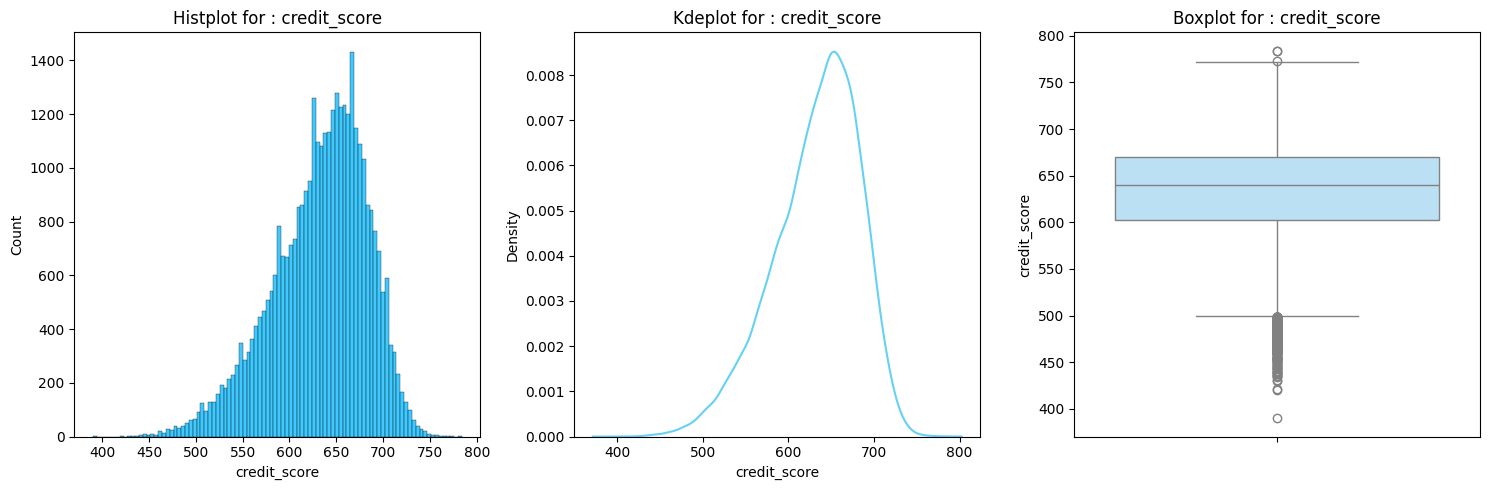

In [45]:
# Credit score 
numeric_column_inspector('credit_score')

The credit score distribution when looked is a bit left skewed but it can be handled.
Linear models like Logistic Regression can handle this much skewness.
If we are using tree models then there is no need to even worry about this 

### Person Employee Experience

    Analysing : person_emp_exp
> These were the results of the code blocks above before any heavy transformation
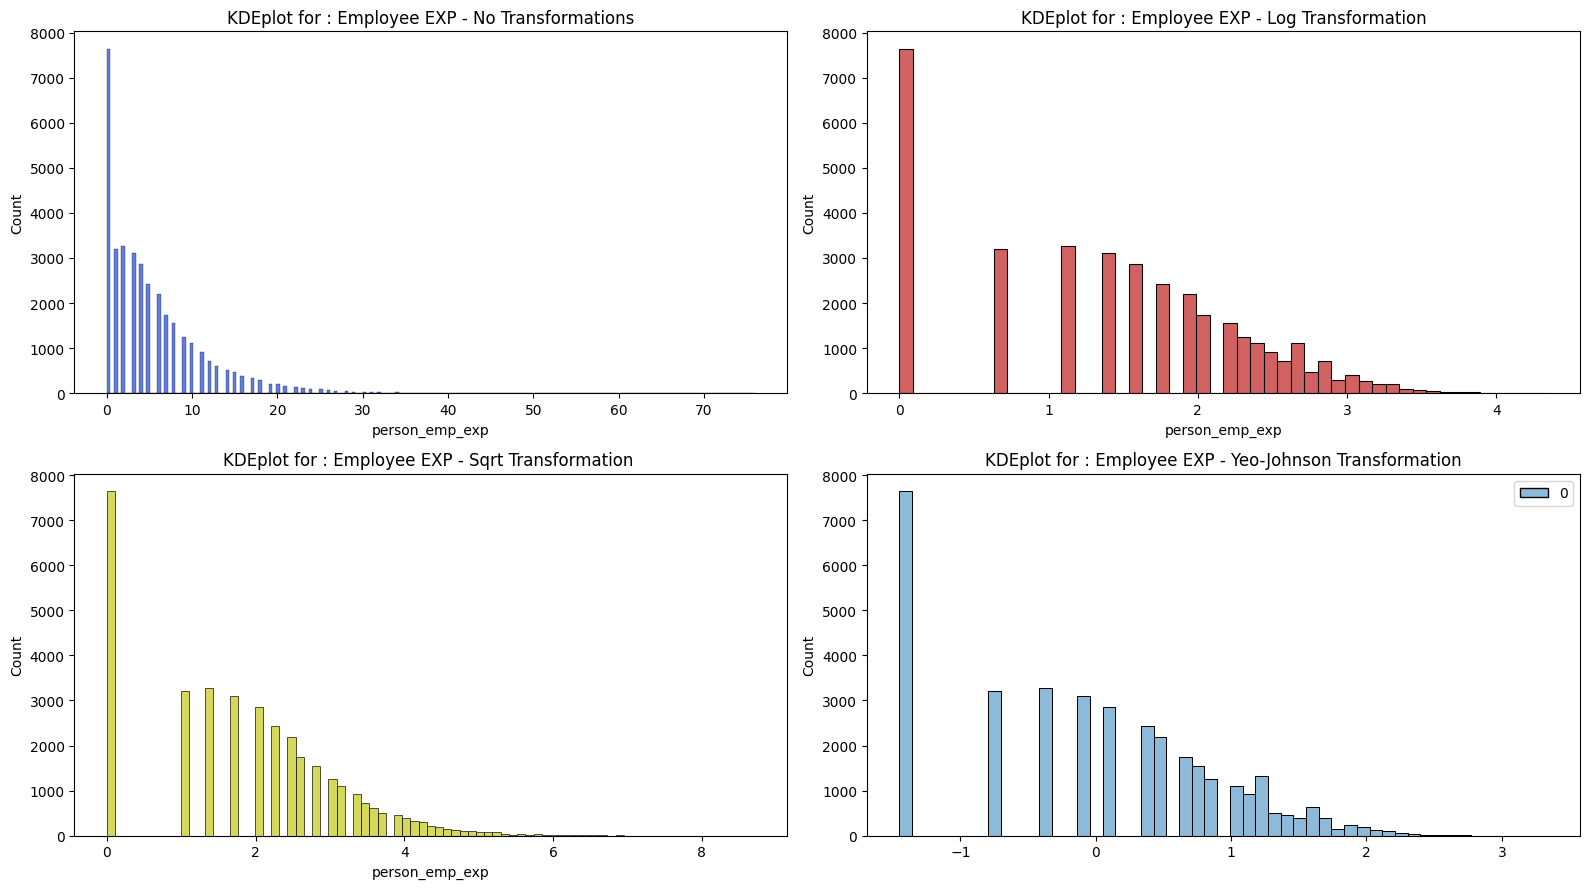
No single continuous transformation can turn this column into a standard Gaussian curve.


In [46]:
"""
    Possible IDEA : 
    
    1. 
        We make a new feature called 'has_no_exp' which is a binary column created from :
            (X_train['person_emp_exp'] == 0).astype('int')
       Then we log transform only the positive values : 
            df['log_positive_exp'] = np.where(df['person_emp_exp'] > 0, np.log(df['person_emp_exp']), 0)
       Then MinMaxScale on the subset explicitly :
            # Find rows where there is experience
                is_experienced = df['log_positive_exp'] > 0

            # Scale only those rows and put them back
                df.loc[is_experienced, 'scaled_log_exp'] = scaler.fit_transform(df.loc[is_experienced, [['log_positive_exp']]])

            # Fill the unscaled zero rows with 0
                df['scaled_log_exp'] = df['scaled_log_exp'].fillna(0)

       Drop the raw column and intermediate log column
                X = df.drop(columns=['person_emp_exp', 'log_positive_exp'])
                
"""

# NOTE : I have decided to make the new feature 'is_exp' after splitting dataset into X_train and X_test and for convenience.
#        I will do all the other steps chained for now to analyze the end results of the feature transformations.
#        This all will be replaced by a custom FunctionTransformer and passed to the pipeline later.

"\n    Possible IDEA : \n\n    1. \n        We make a new feature called 'has_no_exp' which is a binary column created from :\n            (X_train['person_emp_exp'] == 0).astype('int')\n       Then we log transform only the positive values : \n            df['log_positive_exp'] = np.where(df['person_emp_exp'] > 0, np.log(df['person_emp_exp']), 0)\n       Then MinMaxScale on the subset explicitly :\n            # Find rows where there is experience\n                is_experienced = df['log_positive_exp'] > 0\n\n            # Scale only those rows and put them back\n                df.loc[is_experienced, 'scaled_log_exp'] = scaler.fit_transform(df.loc[is_experienced, [['log_positive_exp']]])\n\n            # Fill the unscaled zero rows with 0\n                df['scaled_log_exp'] = df['scaled_log_exp'].fillna(0)\n\n       Drop the raw column and intermediate log column\n                X = df.drop(columns=['person_emp_exp', 'log_positive_exp'])\n\n"

In [47]:
# 1 . Now we create a new column is_exp as planned
X_train['is_exp'] = (X_train['person_emp_exp'] == 0).astype('int')
X_test['is_exp'] = (X_test['person_emp_exp'] == 0).astype('int')

# 2.  Creating a new column for only positive values in person_emp_exp
X_train['log_positive_exp'] = np.where(
                                    X_train['person_emp_exp'] > 0, 
                                    np.log1p(X_train['person_emp_exp'])
                                    , 0)
X_test['log_positive_exp'] = np.where(
                                    X_test['person_emp_exp'] > 0, 
                                    np.log1p(X_test['person_emp_exp'])
                                    , 0)


# 3. Transforming only the positive values using a MinMaxScaller
min_max = MinMaxScaler()

min_max.fit(X_train[['log_positive_exp']])

X_train['scaled_log_exp'] = min_max.transform(X_train[['log_positive_exp']] > 0)
X_test['scaled_log_exp'] = min_max.transform(X_test[['log_positive_exp']] > 0)

# 4. Drop the redundant cols
X_train = X_train.drop(columns=['log_positive_exp','person_emp_exp'])
X_test = X_test.drop(columns=['log_positive_exp','person_emp_exp'])

# NOTE : There are dozens of more effecient way for this but the analysis is more important at the stage

In [48]:
# The steps have been implemented above and we have a new column to analyze now in case of person_emp_exp

In [49]:
X_train.head()
# new cols added : is_exp , scaled_log_exp

,person_age,person_gender,person_education,person_income,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,credit_score,previous_loan_defaults_on_file,is_exp,scaled_log_exp
0,31.0,female,Associate,44485.0,RENT,8000.0,PERSONAL,8.83,0.18,668,Yes,0,0.230213
1,24.0,female,Master,35851.0,RENT,8725.0,MEDICAL,12.18,0.24,645,Yes,1,0.000000
2,28.0,female,High School,121251.0,MORTGAGE,25000.0,VENTURE,11.01,0.21,569,No,0,0.230213
3,23.0,female,High School,76537.0,RENT,12000.0,MEDICAL,14.96,0.16,538,No,0,0.230213
4,24.0,male,Associate,53633.0,RENT,23975.0,HOMEIMPROVEMENT,11.01,0.45,678,No,0,0.230213


Inspection on scaled_log_exp : 



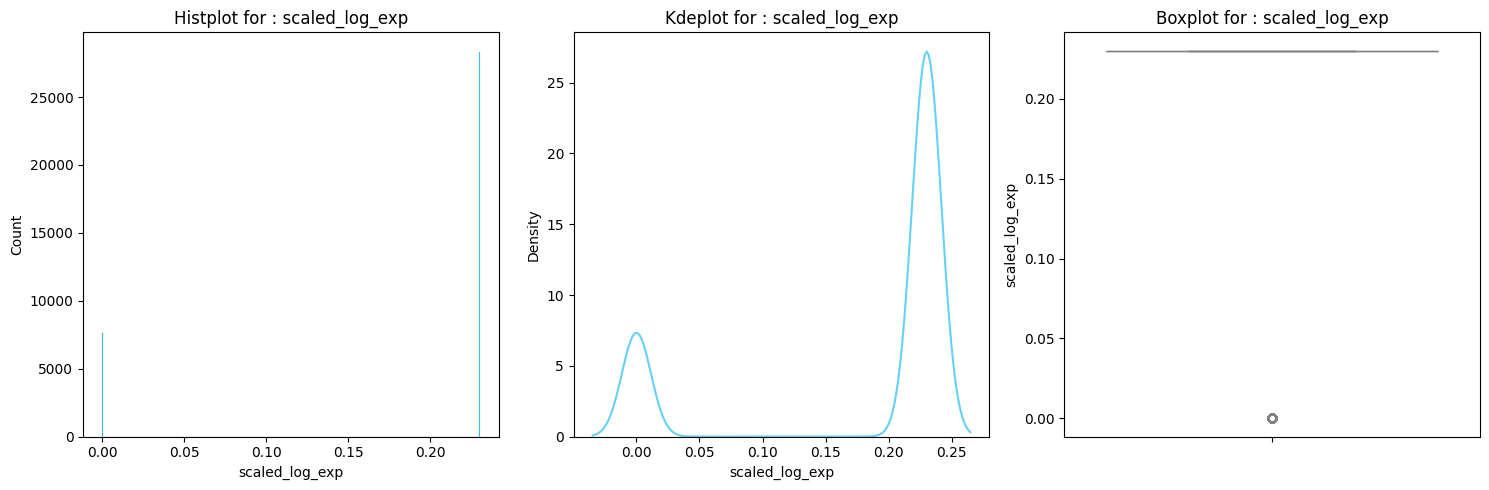

In [50]:
# Log_Scalled_Exp 
numeric_column_inspector('scaled_log_exp')

In [51]:
# Far better results on linear models then what we had previously also we have a new column to mark the behaviour :  whether a person is exp or not

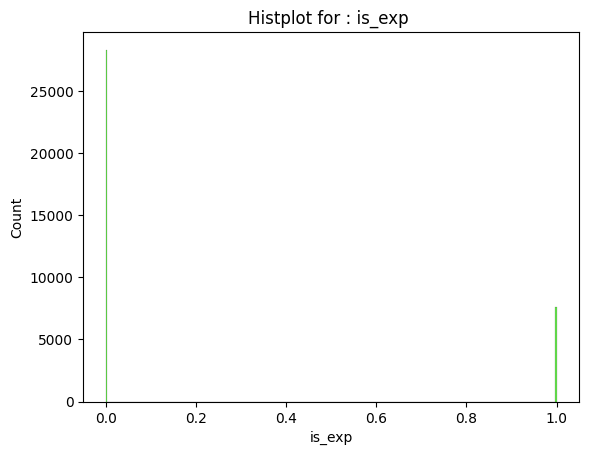

In [53]:
sns.histplot(data=X_train['is_exp'],color="#33DC12F5",binrange=[0,1])
plt.title("Histplot for : is_exp ")
plt.show()

For a peson's experience we ended up making two numeric columns and dropped the original column due to many people having no experience.
We ended up analyzing also the minmaxscaler's effect on the people who have exp . Further this step must be done by either using a custom MinMaxScaller for exclusively this column or any other method during chaining steps in ColumnTransformer and Pipelining.

### Person's Age

Inspection on person_age : 



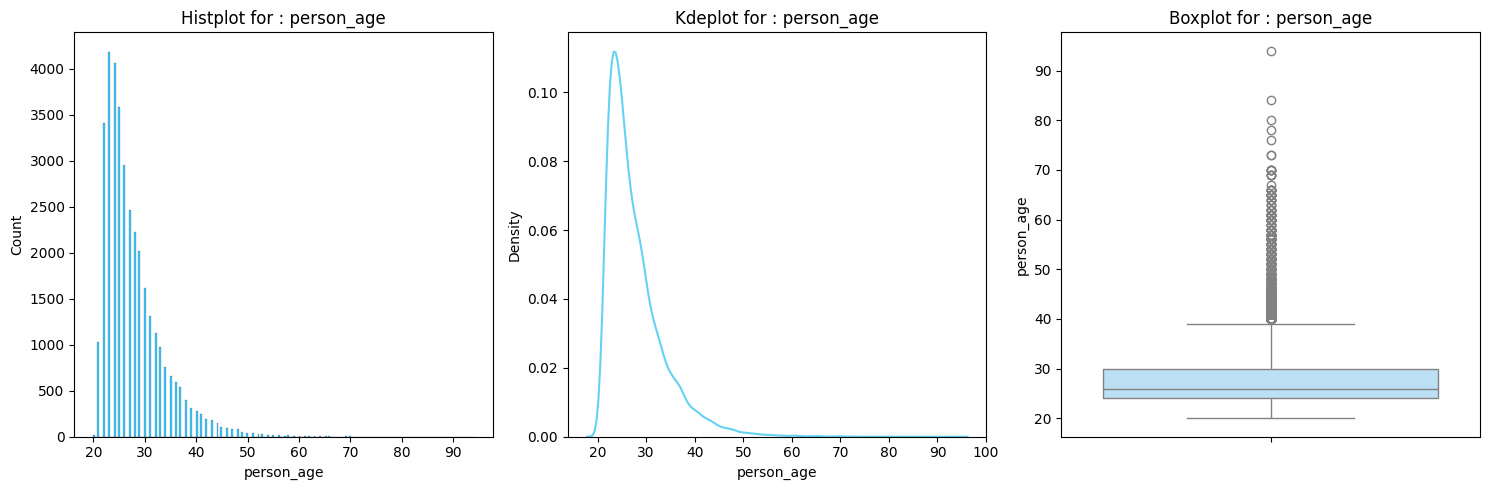

In [54]:
# person_age 
numeric_column_inspector('person_age')

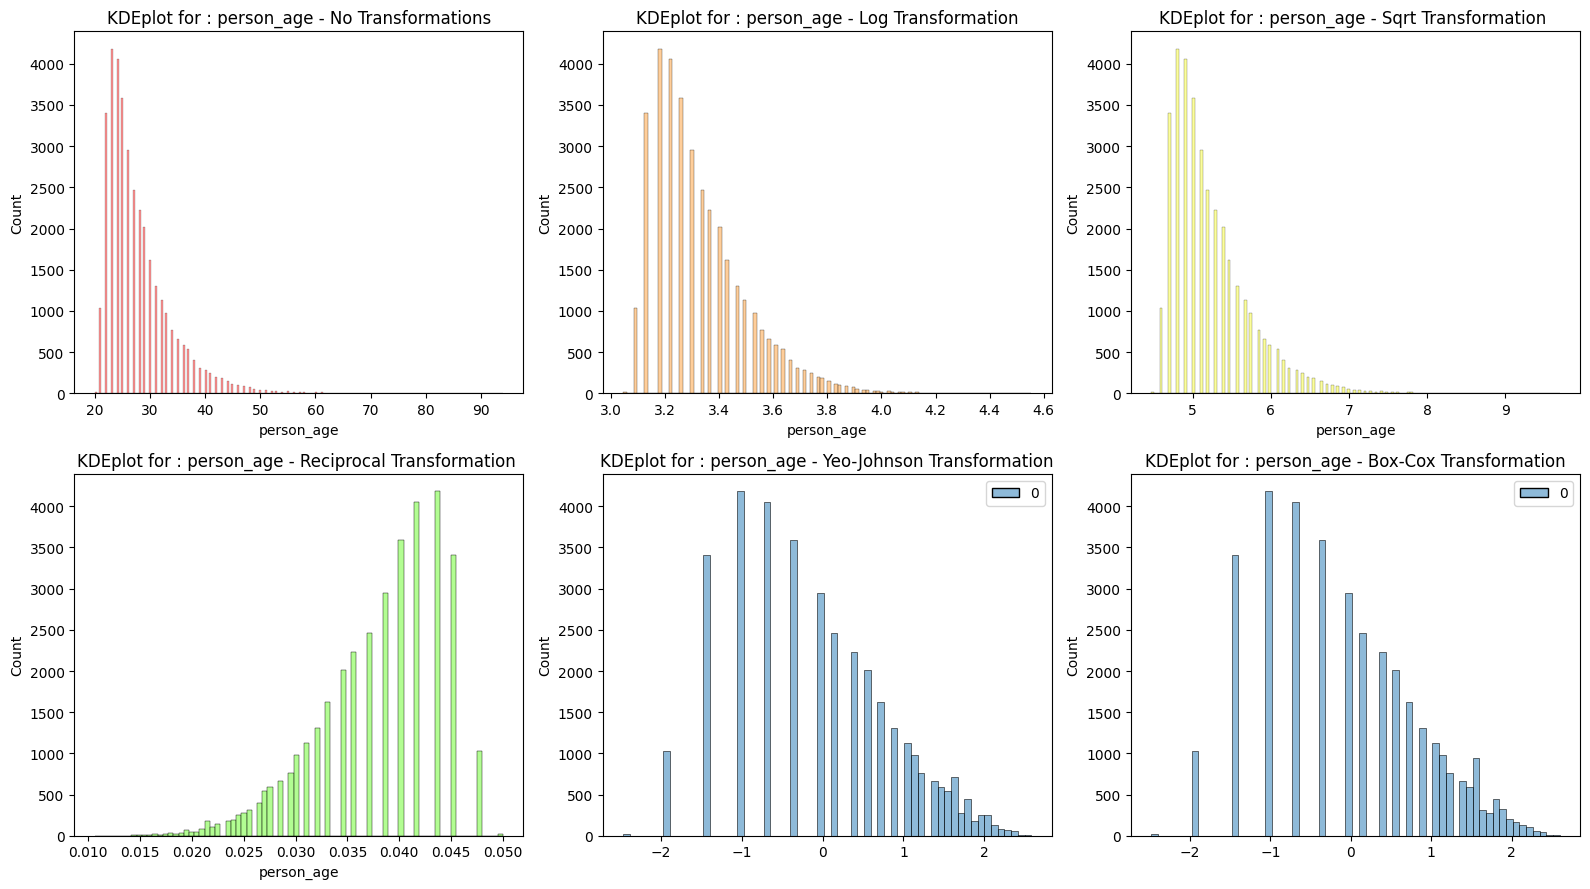

In [55]:
# The age distribution is completely left right skewed ~ Let's make some transformations on this col to look for some ways to fix this 
# We already did this step before using a custom function 
# Experimenting different transformation on Person Age

right_skewed_transformer('person_age')

In [ ]:
# We just cannot use yeo-johnson nor box cox cause our values cannot be negative 
# Also other transformation do not affect the distribution unless Repciprocal ~ Made it left skewed

Inspection on person_income : 



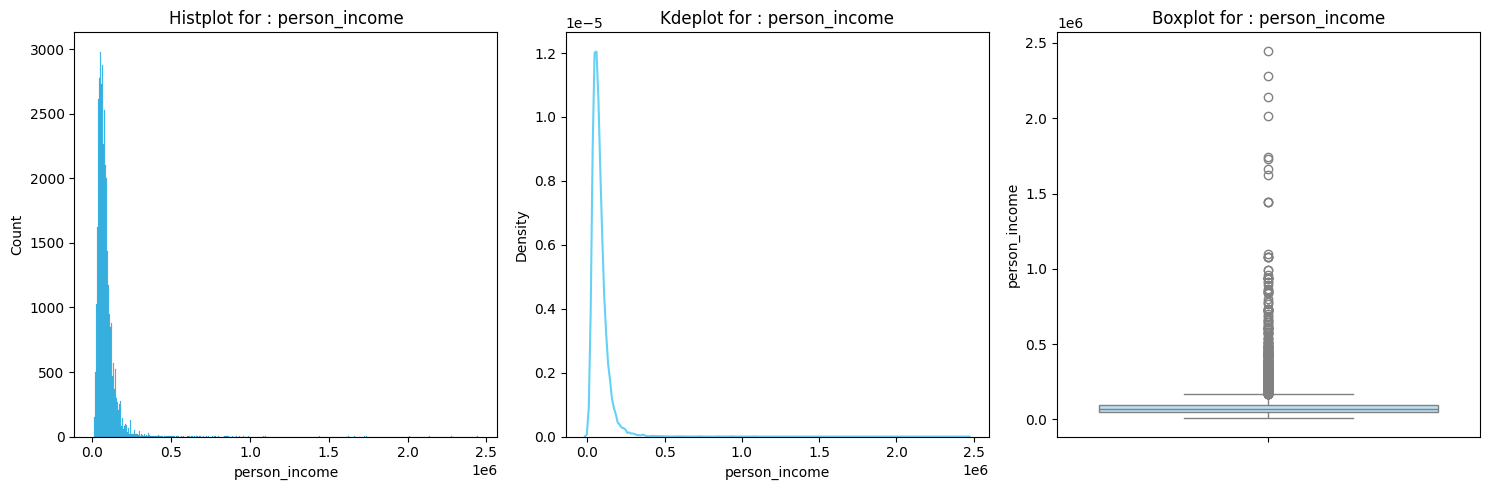

In [ ]:
# Person Income
numeric_column_inspector('person_income')

In [ ]:
# Most of the people have a low income according to the distribution.

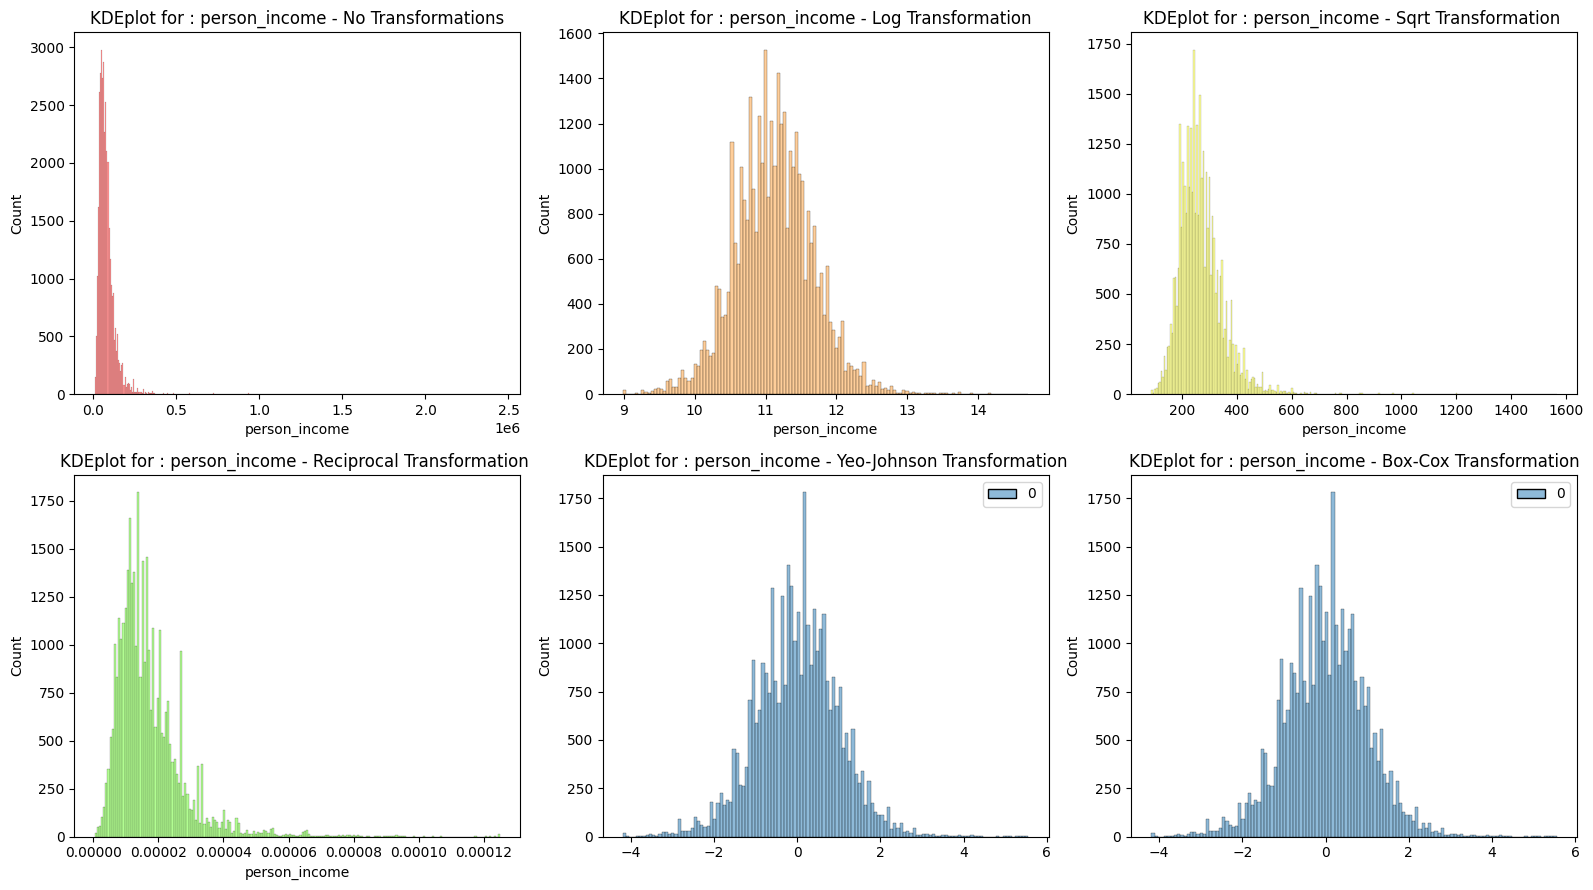

In [ ]:
right_skewed_transformer('person_income') 
# Calling uppon our custom transformer to peek into and look what happens when different transformations are applied to a numeric column

In [ ]:
# We can clearly see that log Transformer works perfectly for this .
# To be Handled in Column Transformer

Inspection on loan_amnt : 



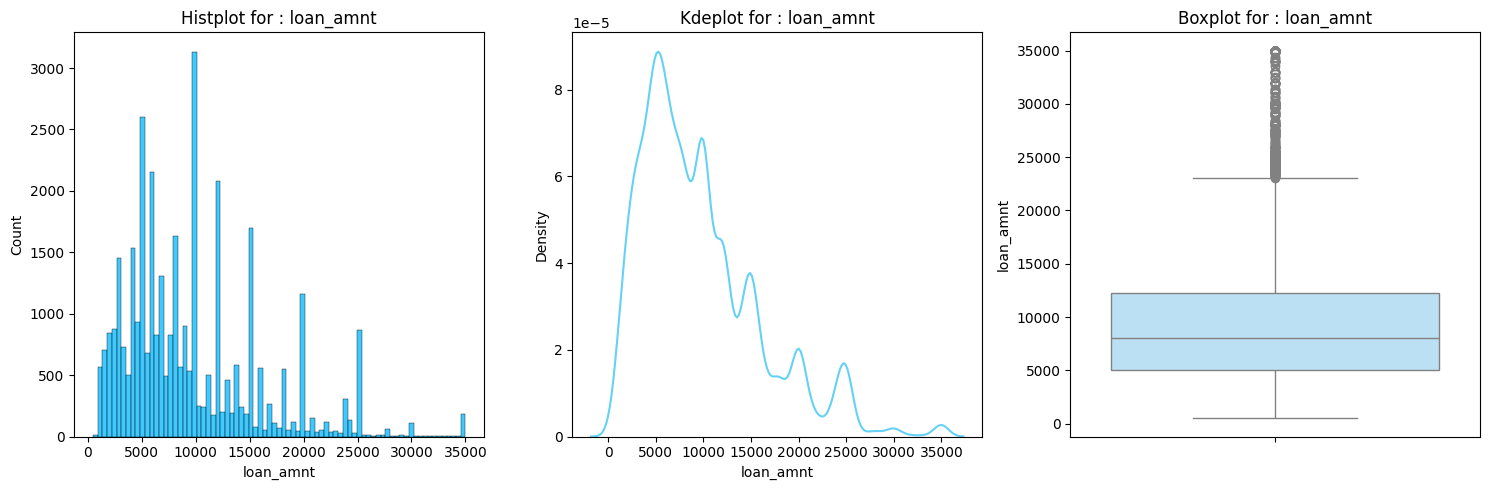

In [ ]:
# Loan Amount
numeric_column_inspector('loan_amnt')

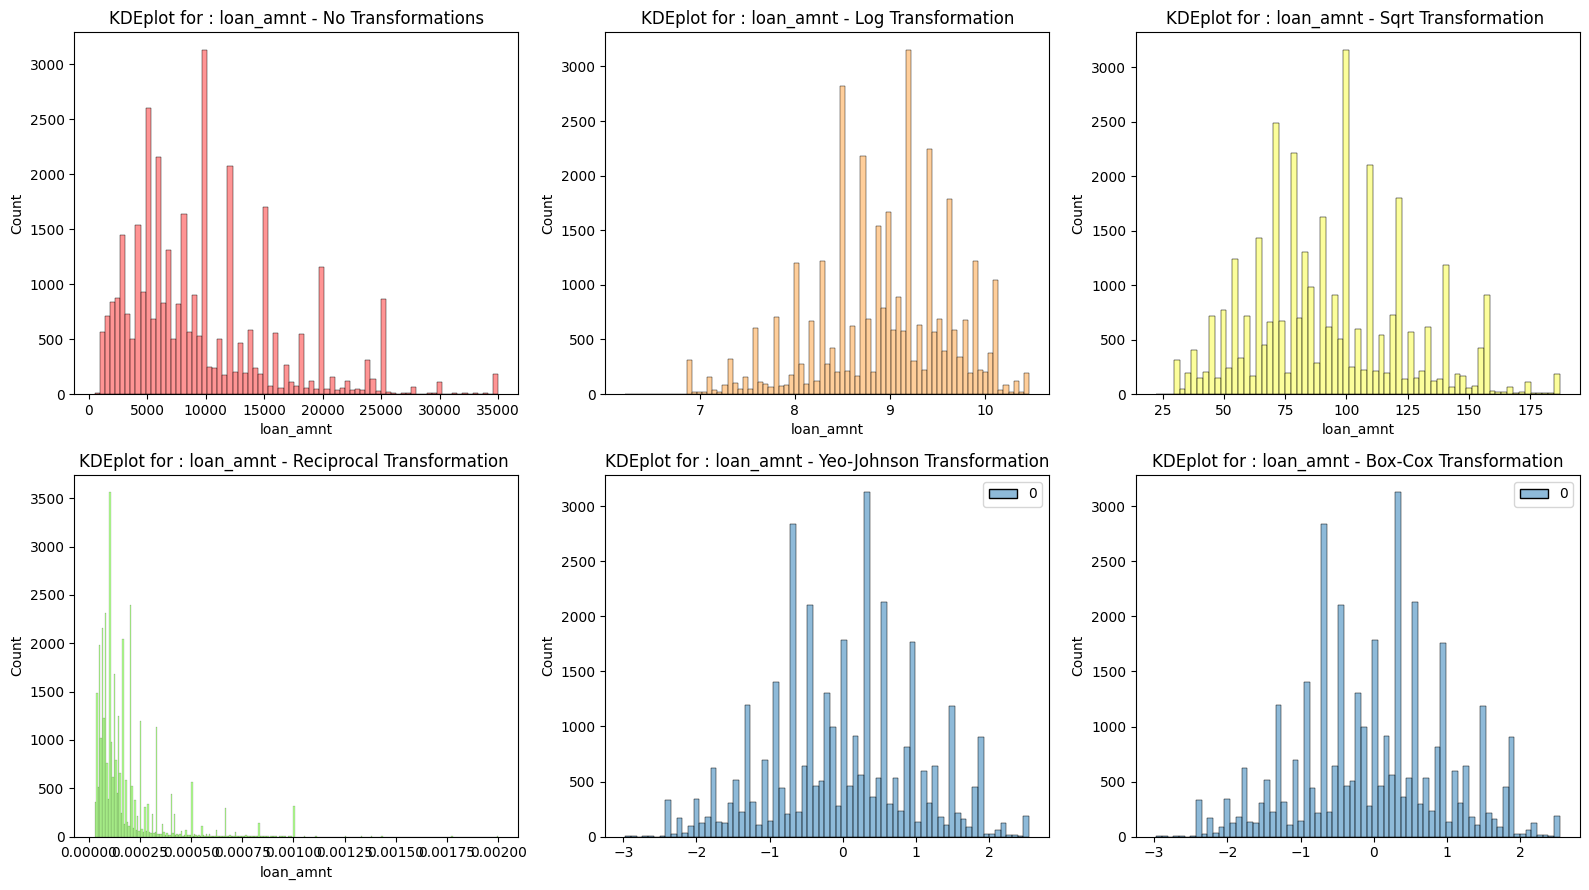

In [ ]:
# This feature column is jaggered in nature , we need to treat this column no matter what ! 
right_skewed_transformer('loan_amnt')

In [ ]:
# For loan_amnt sqrt transformer seems to work the best 

Inspection on loan_int_rate : 



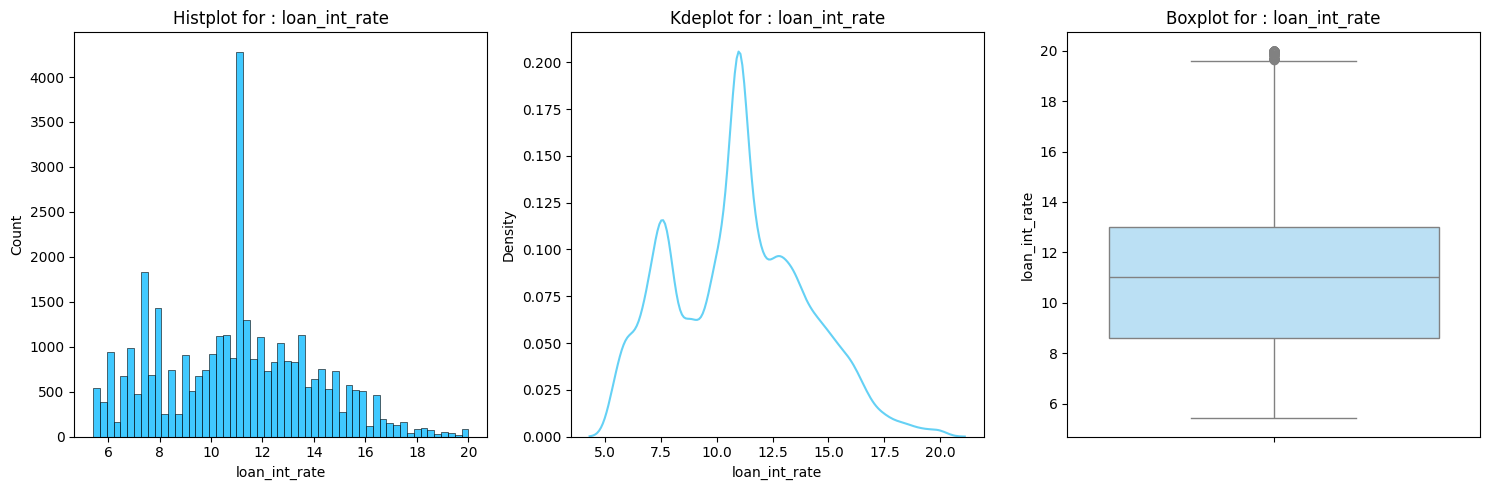

In [ ]:
# Loan Interest Rate
numeric_column_inspector('loan_int_rate')

In [ ]:
# Here we get to see that most of the tuples have a loan_int_rate of 11 
# We will convert this into into two bins <11 or >11 

Inspection on loan_percent_income : 



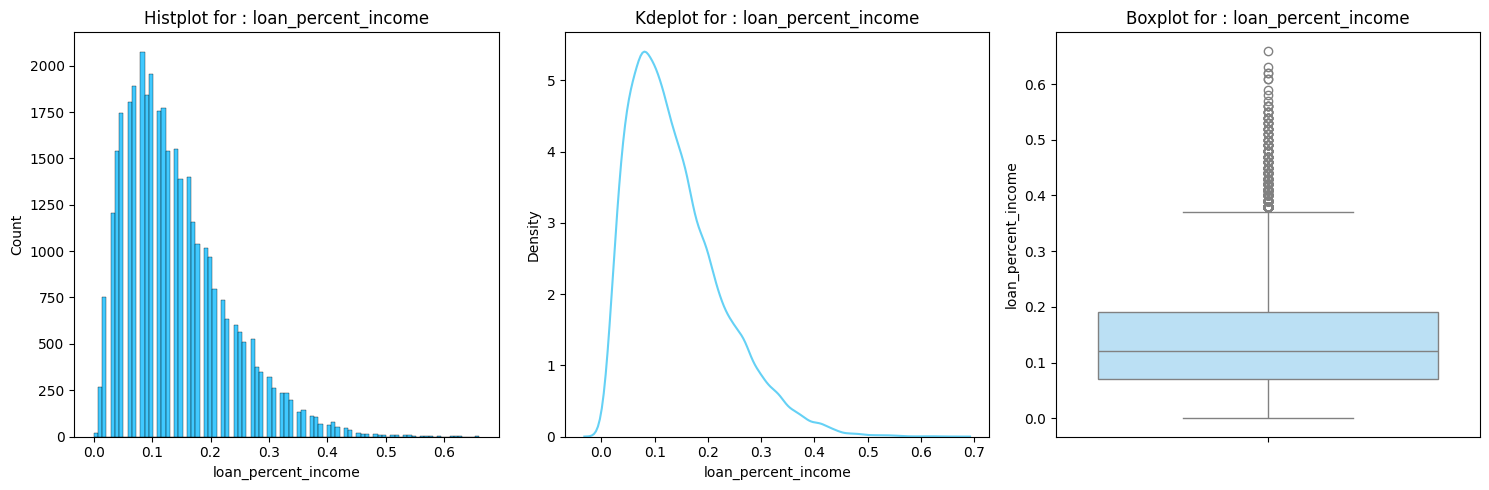

In [ ]:
# Loan Percent Income
numeric_column_inspector('loan_percent_income')

In [ ]:
# The column is purely right skewed
# right_skewed_transformer('loan_percent_income')

In [ ]:
"""
Pass-through / Drop: cb_person_cred_hist_length (drop)
Log/Sqrt Transformed + Scaled: person_income (Log), loan_amnt (Sqrt), loan_percent_income (Log)
Custom Transformed: person_emp_exp (Zero-inflated custom transform)
Binned / Discretized: loan_int_rate
MinMax Scaled (As-is): credit_score, person_age (or Yeo-Johnson scaled)
"""

'\nPass-through / Drop: cb_person_cred_hist_length (drop)\nLog/Sqrt Transformed + Scaled: person_income (Log), loan_amnt (Sqrt), loan_percent_income (Log)\nCustom Transformed: person_emp_exp (Zero-inflated custom transform)\nBinned / Discretized: loan_int_rate\nMinMax Scaled (As-is): credit_score, person_age (or Yeo-Johnson scaled)\n'